#1: Imports and Path Setup

In [1]:
import os
import sys
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

In [2]:
PROJECT_ROOT = '/content/drive/MyDrive/Transformer_Mine'
FIGURES_DIR  = os.path.join(PROJECT_ROOT, 'figures')

In [3]:
from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/Transformer_Mine

Mounted at /content/drive
/content/drive/MyDrive/Transformer_Mine


#  2: Mathematical Foundation (Documentation)

From the paper (Section 3.5):

$$
PE(pos, 2i) = \sin\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)
$$

$$
PE(pos, 2i+1) = \cos\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)
$$

Where:

- `pos` : position in the sequence (0, 1, 2, ..., max_len-1)
- `i` : dimension index (0, 1, 2, ..., d_model/2 - 1)
- `2i` : even dimension indices → sine
- `2i+1` : odd dimension indices → cosine

### Key properties:

1. Each position gets a unique encoding vector of size `d_model`.
2. The encoding for position `pos+k` can be expressed as a  
   LINEAR FUNCTION of the encoding for position `pos`.  
   This allows the model to easily attend to relative positions.
3. The values are bounded in `[-1, 1]` — same scale as embeddings  
   after they are scaled by `sqrt(d_model)`.
4. No learned parameters — fixed at construction time.
5. Can generalise to sequences longer than those seen in training.

### Implementation note:

The division `pos / 10000^(2i/d_model)` is computed as:

`pos * exp(-log(10000) * 2i / d_model)`

for numerical stability (avoids computing large powers of `10000`).

### Transformer Base:

- `d_model = 512`
- `max_len = 5000` (paper uses up to 5000 for position encoding)

In [4]:
print("Sinusoidal Positional Encoding — Paper Section 3.5")
print()
print("  PE(pos, 2i)   = sin( pos / 10000^(2i/d_model) )")
print("  PE(pos, 2i+1) = cos( pos / 10000^(2i/d_model) )")
print()
print("Properties:")
print("  - Fixed (no learned parameters)")
print("  - Unique vector per position")
print("  - Bounded in [-1, 1]")
print("  - Linear relationship between relative positions")
print("  - Generalises beyond training sequence lengths")
print()
print("Transformer Base configuration:")
print("  d_model = 512")
print("  max_len = 5000")

Sinusoidal Positional Encoding — Paper Section 3.5

  PE(pos, 2i)   = sin( pos / 10000^(2i/d_model) )
  PE(pos, 2i+1) = cos( pos / 10000^(2i/d_model) )

Properties:
  - Fixed (no learned parameters)
  - Unique vector per position
  - Bounded in [-1, 1]
  - Linear relationship between relative positions
  - Generalises beyond training sequence lengths

Transformer Base configuration:
  d_model = 512
  max_len = 5000


#  3: Positional Encoding Implementation

Implements as a `tf.keras.layers.Layer` so it integrates  
cleanly into the encoder and decoder stacks.

At call time:

- `input` : `(batch, seq_len, d_model)` ← token embeddings
- `output` : `(batch, seq_len, d_model)` ← embeddings + PE

The positional encoding matrix is computed ONCE at `__init__`  
and stored as a non-trainable buffer.  
It is sliced to the actual sequence length at call time.

In [9]:
class PositionalEncoding(tf.keras.layers.Layer):
    """
    Sinusoidal positional encoding from Vaswani et al. 2017.

    PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

    Adds positional information to token embeddings.
    The encoding is fixed (not learned) and computed once.

    Args:
        d_model : embedding dimension (e.g. 512)
        max_len : maximum sequence length to pre-compute (e.g. 5000)
        dropout : dropout rate applied after adding PE (paper: 0.1)

    Input:
        x : (batch, seq_len, d_model) — scaled token embeddings
        training: bool — controls dropout

    Output:
        (batch, seq_len, d_model) — embeddings + positional encoding
    """

    def __init__(self, d_model, max_len=5000, dropout=0.1, **kwargs):
        super().__init__(**kwargs)

        self.d_model = d_model
        self.max_len = max_len
        self.dropout_rate = dropout
        self.supports_masking = True

        self.dropout = tf.keras.layers.Dropout(dropout)

        # Pre-compute positional encoding matrix
        pe = self.build_pe(max_len, d_model)
        self.pe = pe
        # shape: (1, max_len, d_model)

    def build_pe(self, max_len, d_model):
        """
        Compute the full positional encoding matrix.

        Args:
            max_len: number of positions to encode
            d_model: encoding dimension

        Returns:
            pe: float32 tensor of shape (1, max_len, d_model)

        Implementation:
            For numerical stability we compute the denominator as:
                1 / 10000^(2i/d_model)
              = exp(-log(10000) * 2i / d_model)
            This avoids computing 10000^256 for large d_model.
        """

        positions = np.arange(max_len)[:, np.newaxis]
        # positions shape: (max_len, 1)

        i = np.arange(0, d_model, 2)
        # i shape: (d_model//2,)

        div_term = np.exp(-np.log(10000.0) * i / d_model)
        # div_term shape: (d_model//2,)

        angles = positions* div_term
        # angles shape: (max_len, d_model//2)

        pe = np.zeros((max_len, d_model))

        # Even indices → sine
        pe[:, 0::2] = np.sin(angles)

        # Odd indices → cosine
        pe[:, 1::2] = np.cos(angles[:, :d_model//2])

        # Add batch dimension: (max_len, d_model) → (1, max_len, d_model)
        pe = pe[np.newaxis, :, :]

        return tf.cast(pe, dtype=tf.float32)

    def call(self, x, training):
        """
        Add positional encoding to token embeddings.

        From the paper: embeddings are scaled by sqrt(d_model)
        before adding PE, so the PE signal is not drowned out
        by large embedding values.

        Args:
            x: (batch, seq_len, d_model) — token embeddings
            training: controls dropout

        Returns:
            (batch, seq_len, d_model)
        """

        seq_len = tf.shape(x)[1]
        # Scale embeddings by sqrt(d_model) as per paper Section 3.4
        x = x * tf.math.sqrt(tf.cast(self.d_model, tf.float32))

        x = x + self.pe[:, :seq_len, :]

        x = self.dropout(x, training=training)

        return x

    def get_config(self):
        config = super().get_config()

        config.update({
            'd_model' : self.d_model,
            'max_len' : self.max_len,
            'dropout' : self.dropout_rate,
        })

        return config

# 4: Shape and Value Tests

Test 1: Transformer Base dimensions

In [10]:
D_MODEL = 512
MAX_LEN = 5000
BATCH = 2
SEQ_LEN = 100

In [12]:
pe_layer = PositionalEncoding(d_model=D_MODEL, max_len=MAX_LEN, dropout=0.0)

tf.random.set_seed(42)
x_test = tf.random.normal((BATCH, SEQ_LEN, D_MODEL))
output = pe_layer(x_test, training=False)

assert output.shape == (BATCH, SEQ_LEN, D_MODEL), \
    f"Output shape wrong: {output.shape}"
print(f"\nTest 1 — Transformer Base (d_model=512, seq_len=100):")
print(f"Input shape : {x_test.shape}")
print(f"Output shape : {output.shape}  [DONE]")


Test 1 — Transformer Base (d_model=512, seq_len=100):
Input shape : (2, 100, 512)
Output shape : (2, 100, 512)  [DONE]


Test 2: PE matrix shape

In [14]:
assert pe_layer.pe.shape == (1, MAX_LEN, D_MODEL), \
    f"PE matrix shape wrong: {pe_layer.pe.shape}"
print(f"\nTest 2 - PE matrix shape:")
print(f"pe.shape : {pe_layer.pe.shape}  [Done] (1, max_len, d_model)")



Test 2 - PE matrix shape:
pe.shape : (1, 5000, 512)  [Done] (1, max_len, d_model)


Test 3: No learned parameters

In [15]:
n_trainable = len(pe_layer.trainable_weights)
print(f"\nTest 3 - No learned parameters:")
print(f"Trainable weights : {n_trainable}  [Don]  (expected 0)")
assert n_trainable == 0


Test 3 - No learned parameters:
Trainable weights : 0  [Don]  (expected 0)


Test 4: Values bounded in [-1, 1] (before embedding scale)

In [16]:
pe_vals = pe_layer.pe.numpy()
pe_min = pe_vals.min()
pe_max = pe_vals.max()
print(f"\nTest 4 — PE values bounded in [-1, 1]:")
print(f"PE min : {pe_min:.6f}")
print(f"PE max : {pe_max:.6f}")
assert pe_min >= -1.0 - 1e-6 and pe_max <= 1.0 + 1e-6
print(f"All PE values in [-1, 1]")


Test 4 — PE values bounded in [-1, 1]:
PE min : -1.000000
PE max : 1.000000
All PE values in [-1, 1]


Test 5: Even dims are sine, odd dims are cosine

In [17]:
pe_pos0 = pe_layer.pe[0, 0, :].numpy()   # position 0
even_vals = pe_pos0[0::2]   # should all be sin(0) = 0.0
odd_vals = pe_pos0[1::2]   # should all be cos(0) = 1.0
print(f"Even dims (sin) mean : {even_vals.mean():.6f}  (expected 0.0)")
print(f"Odd  dims (cos) mean : {odd_vals.mean():.6f}  (expected 1.0)")
assert abs(even_vals.mean()) < 1e-6, "Even dims should be sin(0)=0"
assert abs(odd_vals.mean() - 1.0) < 1e-6, "Odd dims should be cos(0)=1"
print(f"Sine/cosine pattern verified at position 0")


Even dims (sin) mean : 0.000000  (expected 0.0)
Odd  dims (cos) mean : 1.000000  (expected 1.0)
Sine/cosine pattern verified at position 0


Test 6: Embedding scaling

In [18]:
scale = tf.math.sqrt(tf.cast(D_MODEL, tf.float32)).numpy()
x_np = x_test.numpy()
out_np = output.numpy()
pe_np = pe_layer.pe.numpy()

In [20]:
expected_0 = x_np[0, 0, :] * scale + pe_np[0, 0, :]
actual_0 = out_np[0, 0, :]
max_diff = np.abs(expected_0 - actual_0).max()

print(f"\nTest 6 - Embedding scaling (sqrt({D_MODEL})={scale:.3f}):")
print(f"Max diff from expected (x*sqrt(d_model)+pe) : {max_diff:.2e}")
assert max_diff < 1e-4
print(f"Embedding scaling verified")


Test 6 - Embedding scaling (sqrt(512)=22.627):
Max diff from expected (x*sqrt(d_model)+pe) : 0.00e+00
Embedding scaling verified


# 5: Verify Exact Formula Values

In [21]:
D_SMALL = 8
pe_small = PositionalEncoding(d_model=D_SMALL, max_len=10, dropout=0.0)
pe_mat   = pe_small.pe[0].numpy()   # shape: (10, 8)


In [23]:
print(f"{'pos':<5}", end='')
for dim in range(D_SMALL):
    print(f"dim{dim}", end='')
print()

for pos in range(5):
    print(f"{pos:<5}", end='')
    for dim in range(D_SMALL):
        print(f"  {pe_mat[pos, dim]:+.3f}", end='')
    print()

# Manual verification for pos=1, dim=0 (even → sine)
# PE(1, 0) = sin(1 / 10000^(0/8)) = sin(1.0) ≈ 0.8415
expected_pos1_dim0 = np.sin(1.0 / (10000 ** (0 / D_SMALL)))
actual_pos1_dim0   = pe_mat[1, 0]
print(f"\nManual check - PE(pos=1, dim=0):")
print(f"Formula : sin(1 / 10000^(0/8)) = sin(1.0) = {expected_pos1_dim0:.6f}")
print(f"  Computed: {actual_pos1_dim0:.6f}")
assert abs(expected_pos1_dim0 - actual_pos1_dim0) < 1e-6
print(f"Match")

# Manual verification for pos=1, dim=1 (odd → cosine)
# PE(1, 1) = cos(1 / 10000^(0/8)) = cos(1.0) ≈ 0.5403
expected_pos1_dim1 = np.cos(1.0 / (10000 ** (0 / D_SMALL)))
actual_pos1_dim1 = pe_mat[1, 1]
print(f"\nManual check - PE(pos=1, dim=1):")
print(f"Formula : cos(1 / 10000^(0/8)) = cos(1.0) = {expected_pos1_dim1:.6f}")
print(f"Computed: {actual_pos1_dim1:.6f}")
assert abs(expected_pos1_dim1 - actual_pos1_dim1) < 1e-6
print(f"Match")

# Manual verification for pos=2, dim=4 (even → sine)
# PE(2, 4) = sin(2 / 10000^(4/8)) = sin(2/100) ≈ sin(0.02)
expected_pos2_dim4 = np.sin(2.0 / (10000 ** (4 / D_SMALL)))
actual_pos2_dim4   = pe_mat[2, 4]
print(f"\nManual check — PE(pos=2, dim=4):")
print(f"  Formula : sin(2 / 10000^(4/8)) = {expected_pos2_dim4:.6f}")
print(f"  Computed: {actual_pos2_dim4:.6f}")
assert abs(expected_pos2_dim4 - actual_pos2_dim4) < 1e-6
print(f"Match")


pos  dim0dim1dim2dim3dim4dim5dim6dim7
0      +0.000  +1.000  +0.000  +1.000  +0.000  +1.000  +0.000  +1.000
1      +0.841  +0.540  +0.100  +0.995  +0.010  +1.000  +0.001  +1.000
2      +0.909  -0.416  +0.199  +0.980  +0.020  +1.000  +0.002  +1.000
3      +0.141  -0.990  +0.296  +0.955  +0.030  +1.000  +0.003  +1.000
4      -0.757  -0.654  +0.389  +0.921  +0.040  +0.999  +0.004  +1.000

Manual check - PE(pos=1, dim=0):
Formula : sin(1 / 10000^(0/8)) = sin(1.0) = 0.841471
  Computed: 0.841471
Match

Manual check - PE(pos=1, dim=1):
Formula : cos(1 / 10000^(0/8)) = cos(1.0) = 0.540302
Computed: 0.540302
Match

Manual check — PE(pos=2, dim=4):
  Formula : sin(2 / 10000^(4/8)) = 0.019999
  Computed: 0.019999
Match


#  6: Visualise the PE Matrix

Plots the positional encoding matrix as a heatmap.  
Each row is a position, each column is a dimension.

The sinusoidal pattern should be clearly visible:

- Low dimensions: fast oscillation (high frequency)
- High dimensions: slow oscillation (low frequency)

This is the figure referenced in the paper.

In [24]:
D_MODEL_VIS = 512
MAX_POS_VIS = 200

In [25]:
pe_vis = PositionalEncoding(d_model=D_MODEL_VIS, max_len=MAX_POS_VIS, dropout=0.0)
pe_mat_vis = pe_vis.pe[0, :MAX_POS_VIS, :].numpy()

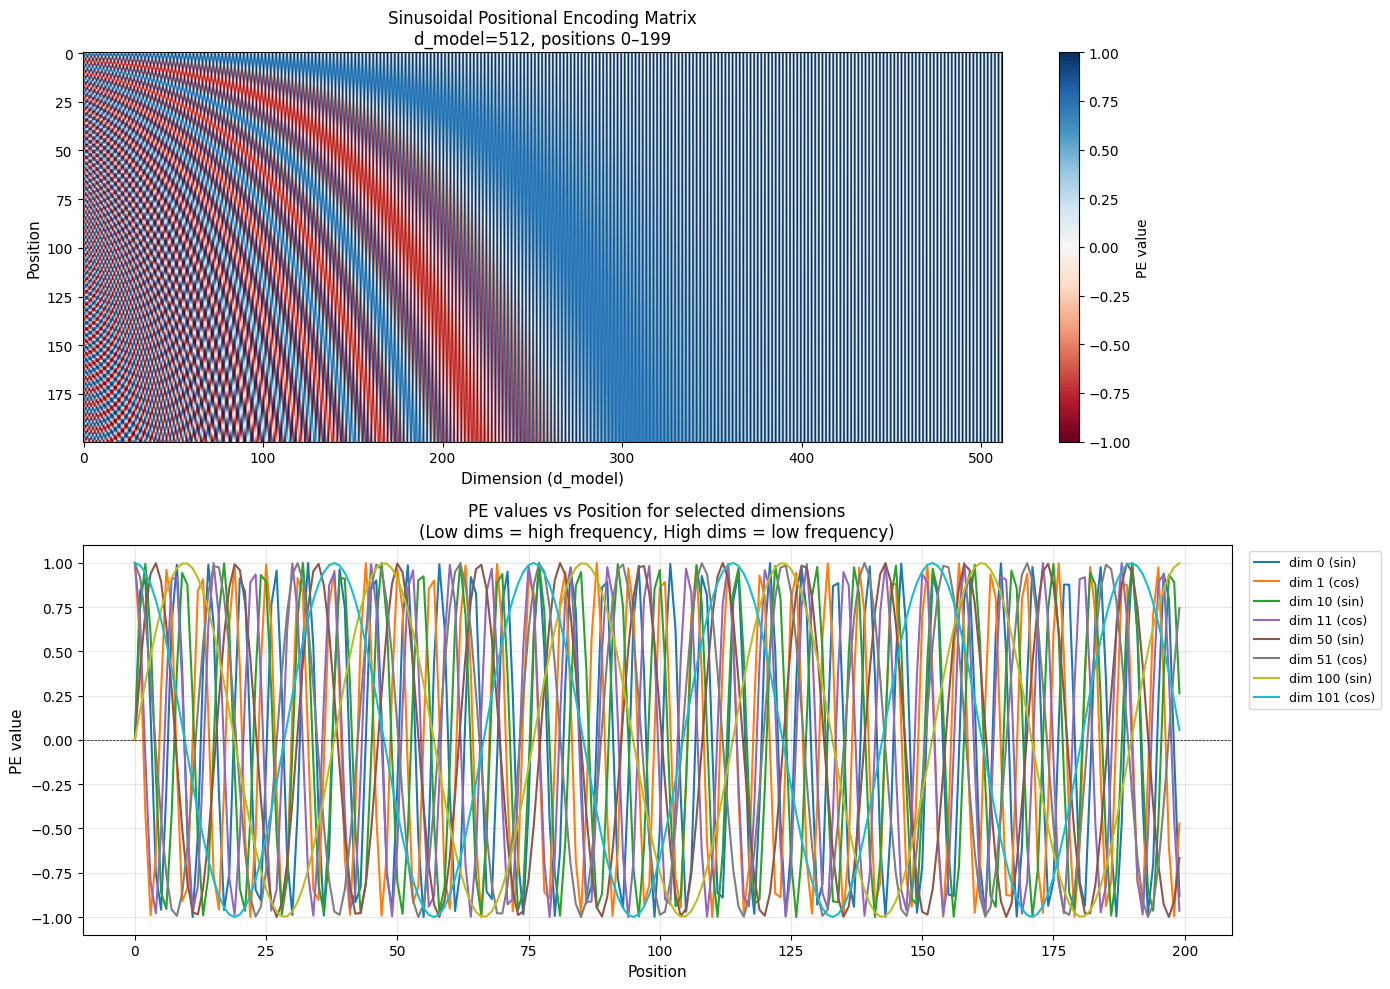

Positional encoding figure saved to:
/content/drive/MyDrive/Transformer_Mine/figures/positional_encoding.png

What the plot shows:
Each row (position) has a unique encoding vector
Low dimensions oscillate quickly (high frequency)
High dimensions oscillate slowly (low frequency)
This gives each position a unique binary-like signature


In [27]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# ── Plot 1: Full PE heatmap ───────────────────────────────────
ax1 = axes[0]
im1 = ax1.imshow(
    pe_mat_vis,
    cmap='RdBu',
    aspect='auto',
    vmin=-1, vmax=1,
    origin='upper',
)
plt.colorbar(im1, ax=ax1, label='PE value')
ax1.set_xlabel('Dimension (d_model)', fontsize=11)
ax1.set_ylabel('Position', fontsize=11)
ax1.set_title(
    f'Sinusoidal Positional Encoding Matrix\n'
    f'd_model={D_MODEL_VIS}, positions 0–{MAX_POS_VIS-1}',
    fontsize=12
)

# ── Plot 2: PE values for selected dimensions ─────────────────
ax2 = axes[1]
positions = np.arange(MAX_POS_VIS)
dims_to_plot = [0, 1, 10, 11, 50, 51, 100, 101]
colors = plt.cm.tab10(np.linspace(0, 1, len(dims_to_plot)))

for dim, color in zip(dims_to_plot, colors):
    label = f'dim {dim} ({"sin" if dim % 2 == 0 else "cos"})'
    ax2.plot(positions, pe_mat_vis[:, dim], label=label,
             color=color, linewidth=1.5)

ax2.set_xlabel('Position', fontsize=11)
ax2.set_ylabel('PE value', fontsize=11)
ax2.set_title(
    'PE values vs Position for selected dimensions\n'
    '(Low dims = high frequency, High dims = low frequency)',
    fontsize=12
)
ax2.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax2.set_ylim(-1.1, 1.1)
ax2.axhline(0, color='black', linewidth=0.5, linestyle='--')
ax2.grid(True, alpha=0.3)

plt.tight_layout()

fig_path = os.path.join(FIGURES_DIR, 'positional_encoding.png')
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()

print(f"Positional encoding figure saved to:")
print(f"{fig_path}")
print()
print("What the plot shows:")
print("Each row (position) has a unique encoding vector")
print("Low dimensions oscillate quickly (high frequency)")
print("High dimensions oscillate slowly (low frequency)")
print("This gives each position a unique binary-like signature")

# 7: Unique Position Test

Verifies that no two positions share the same encoding vector.  
If any two positions were identical, the model could not  
distinguish between them.

In [28]:
D_MODEL_U = 512
MAX_LEN_U = 5000

In [29]:
pe_unique = PositionalEncoding(d_model=D_MODEL_U, max_len=MAX_LEN_U, dropout=0.0)
pe_mat_u  = pe_unique.pe[0].numpy()

In [30]:
pe_mat_u.shape

(5000, 512)

In [31]:
np.random.seed(42)
sample_positions = np.random.choice(MAX_LEN_U, size=500, replace=False)

In [32]:


print(f"\nChecking {MAX_LEN_U} positions for uniqueness ...")

duplicates = 0
for i in sample_positions:
    for j in sample_positions:
        if i == j:
            continue
        diff = np.abs(pe_mat_u[i] - pe_mat_u[j]).max()
        if diff < 1e-6:
            duplicates += 1
            print(f"  X Positions {i} and {j} are identical!")

if duplicates == 0:
    print(f"All sampled positions (n=500) have unique encodings.")
else:
    print(f"X {duplicates} duplicate position encodings found.")



Checking 5000 positions for uniqueness ...
All sampled positions (n=500) have unique encodings.


In [35]:
diffs = []
for pos in range(0, 100):
    diff = np.abs(pe_mat_u[pos] - pe_mat_u[pos + 1]).mean()
    diffs.append(diff)

print(f"Mean diff between adjacent positions (0-99): {np.mean(diffs):.6f}")

print(f"Min diff between adjacent positions (0-99): {np.min(diffs):.6f}")

assert np.min(diffs) > 1e-6, "Adjacent positions should have different encodings"

print(f"All adjacent positions are distinct.")

Mean diff between adjacent positions (0-99): 0.069332
Min diff between adjacent positions (0-99): 0.065652
All adjacent positions are distinct.


# 8: Relative Position Property

The paper states that sinusoidal PE allows the model to  
attend to relative positions because:

$$
PE(pos+k) \text{ can be expressed as a linear function of } PE(pos)
$$

This is because:

$$
\sin(a+b) = \sin(a)\cos(b) + \cos(a)\sin(b)
$$

$$
\cos(a+b) = \cos(a)\cos(b) - \sin(a)\sin(b)
$$

So:

$$
PE(pos+k, 2i) =
PE(pos, 2i) \cdot \cos\left(\frac{k}{10000^{2i/d}}\right)
+
PE(pos, 2i+1) \cdot \sin\left(\frac{k}{10000^{2i/d}}\right)
$$

We verify this numerically for a few positions and offsets.

In [36]:
D_MODEL_R = 64
pe_rel = PositionalEncoding(d_model=D_MODEL_R, max_len=200, dropout=0.0)
pe_r = pe_rel.pe[0].numpy()

In [37]:
pe_r.shape

(200, 64)

In [39]:

test_cases = [(10, 5), (20, 3), (50, 10), (100, 7)]
all_pass   = True

for pos, k in test_cases:
    actual = pe_r[pos + k]

    i = np.arange(0, D_MODEL_R, 2)
    div_term  = np.exp(-np.log(10000.0) * i / D_MODEL_R)
    k_angles = k * div_term

    reconstructed = np.zeros(D_MODEL_R)
    # Even dims
    reconstructed[0::2] = (
        pe_r[pos, 0::2] * np.cos(k_angles)
        + pe_r[pos, 1::2] * np.sin(k_angles)
    )

    # Odd dims
    reconstructed[1::2] = (
        pe_r[pos, 1::2] * np.cos(k_angles)
        - pe_r[pos, 0::2] * np.sin(k_angles)
    )

    max_err = np.abs(actual - reconstructed).max()
    status  = "W" if max_err < 1e-5 else "X"
    if max_err >= 1e-5:
        all_pass = False
    print(f"pos={pos:>3}, k={k:>2}: "
          f"max reconstruction error = {max_err:.2e}  {status}")

if all_pass:
    print(f"\nRelative position property verified.")
    print(f"PE(pos+k) is a linear function of PE(pos) for all tested cases.")
else:
    print(f"\nX Relative position property verification failed.")

pos= 10, k= 5: max reconstruction error = 4.79e-08  W
pos= 20, k= 3: max reconstruction error = 5.32e-08  W
pos= 50, k=10: max reconstruction error = 4.84e-08  W
pos=100, k= 7: max reconstruction error = 5.65e-08  W

Relative position property verified.
PE(pos+k) is a linear function of PE(pos) for all tested cases.


# 9: Gradient Flow Test

Verifies gradients flow through the positional encoding layer.  
Although PE has no learned parameters, gradients must still  
flow THROUGH it back to the embedding layer upstream.

In [40]:
tf.random.set_seed(42)
BATCH_G, SEQ_G, D_G = 2, 10, 512

In [41]:
pe_grad = PositionalEncoding(d_model=D_G, max_len=100, dropout=0.0)
x_grad  = tf.Variable(tf.random.normal((BATCH_G, SEQ_G, D_G)))

In [43]:
with tf.GradientTape() as tape:
    tape.watch(x_grad)
    output_g = pe_grad(x_grad, training=False)
    loss_g = tf.reduce_sum(output_g)

grad = tape.gradient(loss_g, x_grad)

if grad is None:
    print("X Gradient is None — backprop broken through PE layer!")
else:
    grad_norm = tf.norm(grad).numpy()
    has_nan = tf.reduce_any(tf.math.is_nan(grad)).numpy()
    has_inf = tf.reduce_any(tf.math.is_inf(grad)).numpy()
    print(f"Gradient shape : {grad.shape}")
    print(f"Gradient norm  : {grad_norm:.4f}")
    print(f"Has NaN : {has_nan}")
    print(f"Has Inf : {has_inf}")

    assert grad is not None
    assert grad_norm > 0
    assert not has_nan
    assert not has_inf

    expected_grad = tf.math.sqrt(tf.cast(D_G, tf.float32)).numpy()
    actual_grad = grad[0, 0, 0].numpy()

    print(f"\nExpected gradient value : {expected_grad:.4f} (= sqrt({D_G}))")

    print(f"Actual gradient value  : {actual_grad:.4f}")

    assert abs(actual_grad - expected_grad) < 1e-4, \
        f"Gradient value wrong: {actual_grad} vs {expected_grad}"

    print(f"Gradient value correct (= sqrt(d_model))")


Gradient shape : (2, 10, 512)
Gradient norm  : 2289.7334
Has NaN : False
Has Inf : False

Expected gradient value : 22.6274 (= sqrt(512))
Actual gradient value  : 22.6274
Gradient value correct (= sqrt(d_model))


# 10: Save PositionalEncoding to Drive

In [47]:
PE_PY = os.path.join(PROJECT_ROOT, 'positional_encoding.py')

In [48]:
code = '''"""
positional_encoding.py — Sinusoidal Positional Encoding

Usage:
    from google.colab import drive
    drive.mount('/content/drive')
    %cd /content/drive/MyDrive/Transformer_Mine
    from positional_encoding import PositionalEncoding
"""

import numpy as np
import tensorflow as tf


class PositionalEncoding(tf.keras.layers.Layer):
    """
    Sinusoidal positional encoding - Vaswani et al. 2017, Section 3.5.

    PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))

    Args:
        d_model : embedding dimension (e.g. 512)
        max_len : maximum sequence length (e.g. 5000)
        dropout : dropout rate (paper: 0.1)
    """

    def __init__(self, d_model, max_len=5000, dropout=0.1, **kwargs):
        super().__init__(**kwargs)
        self.d_model = d_model
        self.max_len = max_len
        self.dropout_rate = dropout
        self.supports_masking = True
        self.dropout = tf.keras.layers.Dropout(dropout)
        self.pe = self._build_pe(max_len, d_model)

    def _build_pe(self, max_len, d_model):
        positions = np.arange(max_len)[:, np.newaxis]
        i = np.arange(0, d_model, 2)
        div_term = np.exp(-np.log(10000.0) * i / d_model)
        angles = positions * div_term
        pe = np.zeros((max_len, d_model))
        pe[:, 0::2] = np.sin(angles)
        pe[:, 1::2] = np.cos(angles[:, :d_model // 2])
        return tf.cast(pe[np.newaxis, :, :], dtype=tf.float32)

    def call(self, x, training=False):
        seq_len = tf.shape(x)[1]
        x = x * tf.math.sqrt(tf.cast(self.d_model, tf.float32))
        x = x + self.pe[:, :seq_len, :]
        return self.dropout(x, training=training)

    def get_config(self):
        config = super().get_config()
        config.update({
            "d_model" : self.d_model,
            "max_len" : self.max_len,
            "dropout" : self.dropout_rate,
        })
        return config
'''



In [49]:
with open(PE_PY, 'w', encoding='utf-8') as f:
    f.write(code)

In [50]:
import importlib
import positional_encoding
importlib.reload(positional_encoding)
from positional_encoding import PositionalEncoding as PE_loaded

pe_reload = PE_loaded(d_model=512, max_len=5000, dropout=0.0)
x_r = tf.random.normal((2, 50, 512))
out_r = pe_reload(x_r, training=False)

assert out_r.shape == (2, 50, 512)
assert len(pe_reload.trainable_weights) == 0
assert pe_reload.pe.shape == (1, 5000, 512)

print(f"positional_encoding.py saved and reloaded.")
print(f"Path: {PE_PY}")
print()
print("Final verification:")
print(f"Output shape: {out_r.shape}")
print(f"PE matrix shape : {pe_reload.pe.shape}")
print(f"Trainable params : {len(pe_reload.trainable_weights)}")


positional_encoding.py saved and reloaded.
Path: /content/drive/MyDrive/Transformer_Mine/positional_encoding.py

Final verification:
Output shape: (2, 50, 512)
PE matrix shape : (1, 5000, 512)
Trainable params : 0
